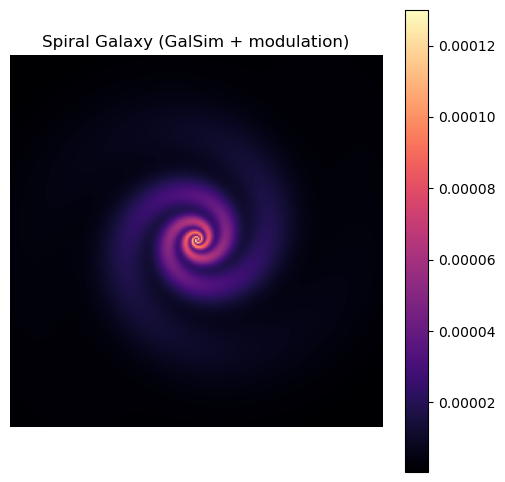

In [11]:
import galsim
import numpy as np
import matplotlib.pyplot as plt

# Base smooth galaxy (disk)
gal = galsim.Sersic(n=1.5, half_light_radius=5.0)

# Draw base image
nx = 256
scale = 0.05
image = gal.drawImage(nx=nx, ny=nx, scale=scale)
arr = image.array

# Create coordinate grid
y, x = np.indices(arr.shape)
cx, cy = nx // 2, nx // 2

x = (x - cx) * scale
y = (y - cy) * scale

r = np.sqrt(x**2 + y**2)
theta = np.arctan2(y, x)

# ----------------------------
# Spiral modulation (KEY PART)
# ----------------------------
arms = 2
pitch = 0.3  # controls tightness

spiral_pattern = np.cos(arms * (theta - np.log(r + 1e-3) / pitch))

# Turn into brightness modulation
modulation = 1 + 0.4 * spiral_pattern

# Apply modulation
arr_spiral = arr * modulation

# Optional: fade outer regions
arr_spiral *= np.exp(-r / 10)

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(6,6))
plt.imshow(arr_spiral, cmap='magma', origin='lower')
plt.colorbar()
plt.title("Spiral Galaxy (GalSim + modulation)")
plt.axis('off')
plt.show()